In [1]:
import numpy as np
import h5py as h5
import os
import scipy.constants as const
from phonopy import load

## Great, now create a class for an AMM object

In [2]:
class ThermalProperties(object):
    def __init__(self,
                poscar,
                fc_file=None,
                fs_file=None,
                mesh=[11, 11, 11],
                supercell=[2, 2, 2],
                phonopy_yaml=None,
                primitive_flag=None,
                isotropy_flag=True,
                delta_e=0.01):
        print('setting up phonopy from force constants/sets...')
        if phonopy_yaml is None:
            self.phonon = load(supercell_matrix=supercell,
                               primitive_matrix=primitive_flag,
                               unitcell_filename=poscar,
                               force_constants_filename=fc_file,
                               force_sets_filename=fs_file)
        else:
            self.phonon = load(phonopy_yaml=phonopy_yaml,
                               primitive_matrix=primitive_flag,
                               #unitcell_filename=poscar,
                               force_constants_filename=fc_file,
                               force_sets_filename=fs_file)
        print('calculating phonons in mesh mode...')
        self.phonon.run_mesh(mesh, 
                             is_mesh_symmetry=False, 
                             with_eigenvectors=True, 
                             with_group_velocities=True)
        print('done')
        self.AMU = const.physical_constants['atomic mass constant'][0]
        self.AngstromsCubed_to_MetersCubed = 1e-30
        self.THz_to_Hz = 1e12
        self.mesh_dict = self.phonon.get_mesh_dict()
        self.mesh = mesh
        self.sound_speed = self.get_sound_speed(isotropy_flag)
        self.isotropy_flag = isotropy_flag
        self.delta_e = delta_e
        self.get_mode_projected_DOS(self.delta_e)
        self.density = self.get_density()
        num_bins = int(np.ceil(max(self.mesh_dict['frequencies'].reshape(-1)) / 
                                self.delta_e))
        self.freq_list = np.arange(num_bins) * self.delta_e + (delta_e / 2)
        #self.mode_velocities = np.array(self.mesh_dict['mode_velocity'])
    
    def get_density(self):
        AngstromsCubed_to_MetersCubed = 1e-30
        volume = np.linalg.det(self.phonon._primitive.cell) * AngstromsCubed_to_MetersCubed
        return (sum(self.phonon._primitive.masses) * self.AMU) / volume
    
    def get_mode_projected_DOS(self, delta_e=0.01):
        volume = np.linalg.det(self.phonon._primitive.cell) * self.AngstromsCubed_to_MetersCubed
        num_bins = int(np.ceil(max(self.mesh_dict['frequencies'].reshape(-1)) / delta_e))
        
        num_branches = self.phonon.mesh.frequencies.shape[1]
        self.mode_DOS = np.zeros([num_branches, num_bins])
        count = 0
        for f_at_q in self.mesh_dict['frequencies']:
            count += 1
            for j, f in enumerate(f_at_q):
                if count == 1 and j <= 3:
                    continue
                bin_number = np.floor(f / delta_e).astype(int)
                self.mode_DOS[j, bin_number] += (1 / (self.THz_to_Hz * self.delta_e))
        self.mode_DOS /= ((count-3) * volume)
    
    def get_sound_speed(self, isotropy_flag=True):
        if isotropy_flag:
            vels_at_gamma = []
            sound_speeds = np.zeros(3)
            vs = self.mesh_dict['group_velocities'][1, :3, :]
            for i, v in enumerate(vs):
                if np.linalg.norm(v) == 0:
                    vs[i, :] = self.mesh_dict['group_velocities'][2, i, :]
            #vels_at_gamma.append(self.mesh_dict['group_velocities'][1, :3, :])
            vels_at_gamma.append(vs)
            
            vs = self.mesh_dict['group_velocities'][self.mesh[0], :3, :]
            for i, v in enumerate(vs):
                if np.linalg.norm(v) == 0:
                    vs[i, :] = self.mesh_dict['group_velocities'][2 * self.mesh[0], i, :]
            vels_at_gamma.append(vs)
            
            vs = self.mesh_dict['group_velocities'][self.mesh[0] * self.mesh[1], :3, :]
            for i, v in enumerate(vs):
                if np.linalg.norm(v) == 0:
                    vs[i, :] = self.mesh_dict['group_velocities'][2 * self.mesh[0] * self.mesh[1], i, :]
            vels_at_gamma.append(vs)
            
            vels_at_gamma = np.array(vels_at_gamma)
            for vels in vels_at_gamma:
                for j, vel_at_branch in enumerate(vels):
                    sound_speeds[j] += np.linalg.norm(vel_at_branch)
            return sound_speeds * self.THz_to_Hz * (self.AngstromsCubed_to_MetersCubed)**(1/3) / 3.0
            #sound_speeds = [np.linalg.norm(self.mesh_dict['group_velocities'][1, i, :])
            #                for i in range(3)]
            #return np.array(sound_speeds) * self.THz_to_Hz * (self.AngstromsCubed_to_MetersCubed)**(1.0/3)
            #return material.mesh_dict['group_velocities'][1, :3, :]
        else:
            sound_speeds = []
            sound_speeds.append(self.mesh_dict['group_velocities'][1, :3, :])
            sound_speeds.append(self.mesh_dict['group_velocities'][self.mesh[0],
                                                                   :3, :])
            sound_speeds.append(self.mesh_dict['group_velocities'][self.mesh[0] * 
                                                                   self.mesh[1],
                                                                   :3, :])
            #conv_factor = np.sqrt(const.e / self.AMU) / (2 * np.pi)
            return np.array(sound_speeds) * self.THz_to_Hz * (self.AngstromsCubed_to_MetersCubed)**(1/3)
            #return np.array(sound_speeds) * conv_factor
    
    def correct_low_E_DOS(self):
        min_bins = np.array([min(np.where(dos)[0]) for dos in self.mode_DOS])
        for j in range(3):
            min_bin = min_bins[j]
            for i in range(min_bin):
                self.mode_DOS[j, i] = 4 * np.pi * (self.THz_to_Hz * self.freq_list[i])**2 / \
                                                  (self.sound_speed[j]**3)

In [9]:
class AMM(object):
    def __init__(self,
                poscar_1, ## Now will be Si
                poscar_2, ## Will be other materials
                fc_file_1=None,
                fc_file_2=None,
                fs_file_1=None,
                fs_file_2=None,
                phonopy_yaml_1=None,
                phonopy_yaml_2=None,
                T=0.05,  ### 50 mK
                mesh=[11, 11, 11],
                supercell=[2, 2, 2],
                primitive_flag=None,
                isotropy_flag=True,
                delta_e=0.01):
        print('setting thermal properties for material 1')
        self.material_1 = ThermalProperties(poscar_1, 
                                            fc_file=fc_file_1,
                                            fs_file=fs_file_1,
                                            phonopy_yaml=phonopy_yaml_1,
                                            mesh=mesh, 
                                            supercell=supercell, 
                                            primitive_flag=primitive_flag,
                                           delta_e=delta_e)
        print('setting thermal properties for material 2')
        self.material_2 = ThermalProperties(poscar_2, 
                                            fc_file=fc_file_2,
                                            fs_file=fs_file_2,
                                            phonopy_yaml=phonopy_yaml_2,
                                            mesh=mesh, 
                                            supercell=supercell, 
                                            primitive_flag=primitive_flag,
                                           delta_e=delta_e)
        #self.sound_speed_1 = self.material_1.get_sound_speed(self.material_1, isotropy_flag)
        #self.sound_speed_2 = get_sound_speed(self.material_2, isotropy_flag)
        
        self.delta_e = delta_e
        self.T = T
        self.isotropy_flag = isotropy_flag
        num_bins = int(np.ceil(max(self.material_1.mesh_dict['frequencies'].reshape(-1)) / 
                                self.delta_e))
        self.freq_list = np.arange(num_bins) * self.delta_e + (delta_e / 2)
    
    def snells_law(self, theta):  ## Now Si is material 1
        return np.arcsin(self.material_2.sound_speed / self.material_1.sound_speed * np.sin(theta))
    
    def get_alpha(self, theta):
        from math import isnan
        # returns a transmission coefficient for a given propagation angle
        mu = np.cos(theta)
        theta_2 = self.snells_law(theta)
        Z1 = self.material_1.density * self.material_1.sound_speed ## Si impedance
        Z2 = self.material_2.density * self.material_2.sound_speed ## Mats impedance
        alpha = 1 - ((Z1 * np.cos(theta) - Z2 * np.cos(theta_2)) 
                     / (Z1 * np.cos(theta) + Z2 * np.cos(theta_2)))**2
        for i, a in enumerate(alpha):
            if isnan(a):
                alpha[i] = 0.0
        return alpha
    
    def df_dt(self):
        # derivative of bose-einstein distribution
        # frequency in THz==ps^-1
        AMU = const.physical_constants['atomic mass constant'][0]
        kb = const.k
        THz_to_Hz = 1e12
        h = const.h
        return h * self.freq_list * THz_to_Hz / (4 * kb * self.T**2 * 
                                 np.sinh(h * self.freq_list * THz_to_Hz / 
                                         (2 * kb * self.T)))
    def heat_transfer_coeff(self, angle_num_bins):
        # integrate over frequencies
        THz_to_Hz = 1e12
        integrand_1 = np.array([ self.delta_e * THz_to_Hz * sum(const.h * self.freq_list * THz_to_Hz * 
                                                    dos * self.df_dt())
                               for dos in self.material_1.mode_DOS])
        print('integrand_1 =', integrand_1)
        # now integrate over mu
        mu_list = np.linspace(0, 1, angle_num_bins)
        alpha_list = np.array([self.get_alpha(np.arccos(mu)) for mu in mu_list])
        integrand_2 = np.array([np.trapz(alpha * mu_list, mu_list) for alpha in alpha_list.T])
        # now sum over branches
        h_coeff = sum(integrand_1[:3] * integrand_2 * self.material_1.sound_speed) / 2
        return h_coeff

In [10]:
parent_dir = '../dataal/'

# Walk along dirs in this parent folder
## material 1 (Si)
dirs = next(os.walk(parent_dir))[1]
si_dir = '../datasi/Si/' ## check with my own as well
si_poscar = si_dir + 'POSCAR'
si_yaml = si_dir + 'phonopy.yaml'
# al_yaml = None
si_fc = si_dir + 'force_constants.hdf5'

poscar_suffix = 'POSCAR'
yaml_suffix = 'phonopy.yaml'
fs_suffix = 'FORCE_SETS'
fc_suffix = 'force_constants.hdf5'


results = {}
models = {}

for dir_name in dirs:
    # Construct the file paths
    poscar = os.path.join(parent_dir, dir_name, poscar_suffix)
    fs_file = os.path.join(parent_dir, dir_name, fs_suffix)
    yaml_file = os.path.join(parent_dir, dir_name, yaml_suffix)
    fc_file = os.path.join(parent_dir, dir_name, fc_suffix)

    # Check if the required files exist
    if not os.path.exists(poscar):
        print(f"Skipping {dir_name}: POSCAR file not found.")
        continue
    if not os.path.exists(fc_file) and not (os.path.exists(fs_file) and os.path.exists(yaml_file)):
        print(f"Skipping {dir_name}: Required phonon data files not found.")
        continue

    print(f"Processing {dir_name}")
    
    if os.path.exists(fc_file):
        model = AMM(fc_file_1=si_fc,         ## Si is now material 1 
                    poscar_1=si_poscar,
                    phonopy_yaml_1=si_yaml,
                    poscar_2=poscar, ## Other materials are material 2
                    fc_file_2=fc_file,
                    phonopy_yaml_2=yaml_file,
                    primitive_flag=None)
    elif os.path.exists(fs_file) and os.path.exists(yaml_file):
        model = AMM(fc_file_1=si_fc, 
                    poscar_1=si_poscar,
                    phonopy_yaml_1=si_yaml,
                    poscar_2=poscar,
                    fs_file_2=fs_file,
                    phonopy_yaml_2=yaml_file,
                    primitive_flag=None)
    else:
        yaml_file = os.path.join(parent_dir, dir_name, 'phonopy_disp.yaml')
        model = AMM(fc_file_1=si_fc, 
                    poscar_1=si_poscar,
                    phonopy_yaml_1=si_yaml,
                    poscar_2=poscar,
                    fs_file_2=fs_file,
                    phonopy_yaml_2=yaml_file,
                    primitive_flag=None)

    model.material_1.correct_low_E_DOS()  ## Correct Si's DOS
    results[dir_name] = model.heat_transfer_coeff(20)
    models[dir_name] = model

Processing Al
setting thermal properties for material 1
setting up phonopy from force constants/sets...
calculating phonons in mesh mode...
done
setting thermal properties for material 2
setting up phonopy from force constants/sets...
calculating phonons in mesh mode...
done
integrand_1 = [0.00112703 0.00112703 0.00011596 0.         0.         0.        ]


/var/folders/06/9g7wv36n1b39j24_jrtgnp6h0000gn/T/ipykernel_10557/3002361227.py:70: RuntimeWarning: overflow encountered in sinh
  np.sinh(h * self.freq_list * THz_to_Hz /


In [11]:
const.Avogadro

6.02214076e+23

In [12]:
heat_caps = {}
volume = 1e-6         # 1 cm^3
for key in results.keys():
    soundspeed = np.mean(models[key].material_1.get_sound_speed())
    temperature = models[key].T
    debye_temperature = const.h * soundspeed / const.Boltzmann
    heat_cap = 12 * np.pi ** 4 / 5 * const.Avogadro * const.Boltzmann * (temperature / debye_temperature) ** 3
    heat_caps[key] = heat_cap

In [13]:
heat_caps

{'Al': 1.214727773825244e+19}

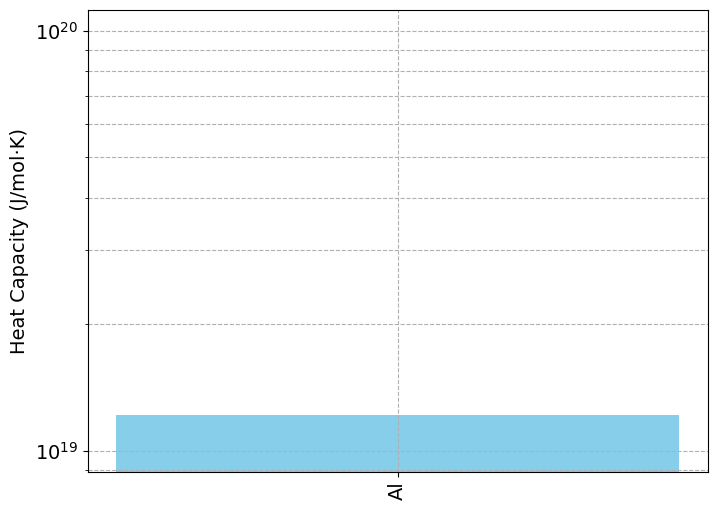

In [14]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({'font.size': 14})

# Example data (replace with your actual `heat_caps` and material names)
heat_caps = {
 'Al': 1.214727773825244e+19}# J/(mol·K)

materials = list(heat_caps.keys())
values = list(heat_caps.values())

plt.figure(figsize=(8, 6))
plt.bar(materials, values, color='skyblue')
plt.yscale('log')  # Log scale for small values
#plt.xlabel('Material')
plt.xticks(rotation=90)
plt.ylabel('Heat Capacity (J/mol·K)')
#plt.title('Low-T Heat Capacity (Debye $T^3$ Law)')
plt.savefig('heat_capacity_Si_Md.png', dpi=400)
plt.grid(True, which="both", ls="--")
plt.show()

In [15]:
energy_dep = 0.1 * const.e       # Converted from 100 meV to Joules

In [16]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})

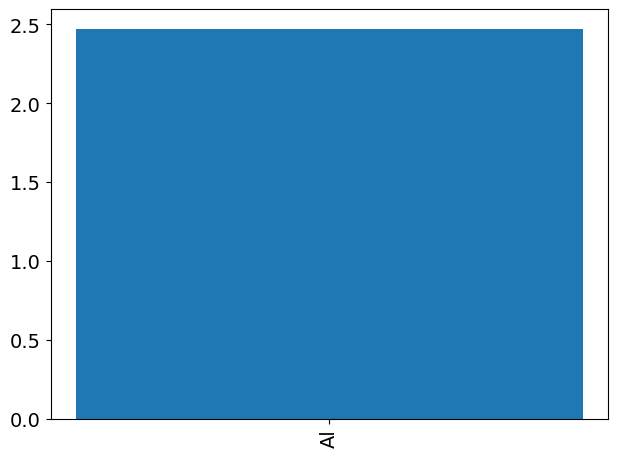

In [17]:
plt.bar(results.keys(), results.values())
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

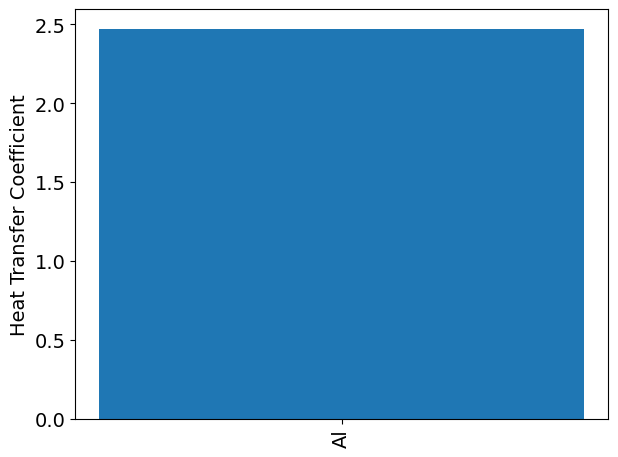

In [18]:
plt.bar(results.keys(), results.values())
plt.xticks(rotation=90)
#plt.xlabel('cos $\Theta$')
plt.ylabel('Heat Transfer Coefficient')
plt.tight_layout()
#plt.savefig('../Figures/heat_transfer.eps')
plt.show()

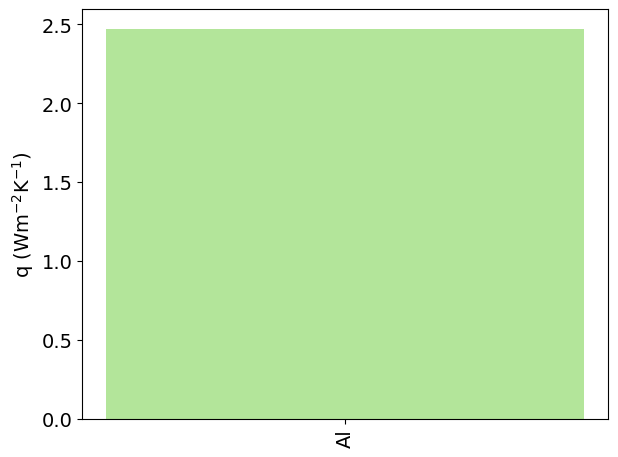

In [19]:
## Matplot.lib
import matplotlib.pyplot as plt

# Update the default font size for the plots
plt.rcParams.update({'font.size': 14})

# Define the scaling factor to convert from m^-2 to cm^-2
#sf= 10**  # 10,000

# Sort the results by heat transfer coefficient (h) and apply the scaling factor
sorted_results = {k: v for k, v in sorted(results.items(), key=lambda item: item[1])}

# Create a bar plot with the specified color
plt.bar(sorted_results.keys(), sorted_results.values(), color='#B3E59A')

# Rotate the x-axis labels by 90 degrees for better readability
plt.xticks(rotation=90)

# Add a y-axis label with the unit
plt.ylabel('q (Wm$^{-2}$K$^{-1}$)') # (Jm$^{-2}$s$^{-1}$K$^{-1}$)
 # This unit represents heat flux per unit temperature gradient
#plt.ylim([0, 3])
# Adjust the plot layout to make sure everything fits within the figure area
plt.tight_layout()

# Save the plot as a PNG file
plt.savefig('1_q_transfer_Si_Al.png', dpi=400)

# Display the plot
plt.show()

In [20]:
#parent_dir = '../Phonons/'
def create_amm_model(material, parent_dir, poscar_suffix, fs_suffix, si_fc, si_poscar, si_yaml):
    poscar = f"{parent_dir}{material}/{poscar_suffix}"
    fs_file = f"{parent_dir}{material}/{fs_suffix}"
    yaml = f"{parent_dir}{material}/phonopy.yaml"

    model = AMM(fc_file_1=si_fc, ## Si 
                poscar_1=si_poscar,
                phonopy_yaml_1=si_yaml,
                poscar_2=poscar,  ## Other mats
                fs_file_2=fs_file,
                phonopy_yaml_2=yaml,
                primitive_flag=None)
    return model

materials = ['Al']
models = {}

for material in materials:
    models[material] = create_amm_model(material, parent_dir, poscar_suffix, fs_suffix, si_fc, si_poscar, si_yaml)

# Now you can access models by material name
cs_model = models['Al'] ## Si to Cs

setting thermal properties for material 1
setting up phonopy from force constants/sets...


/opt/anaconda3/lib/python3.11/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['rotations']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['translations']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['international']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['number']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/spglib/spglib.py:115: DeprecationWarning: di

calculating phonons in mesh mode...
done
setting thermal properties for material 2
setting up phonopy from force constants/sets...
calculating phonons in mesh mode...
done


### Plot for all materials

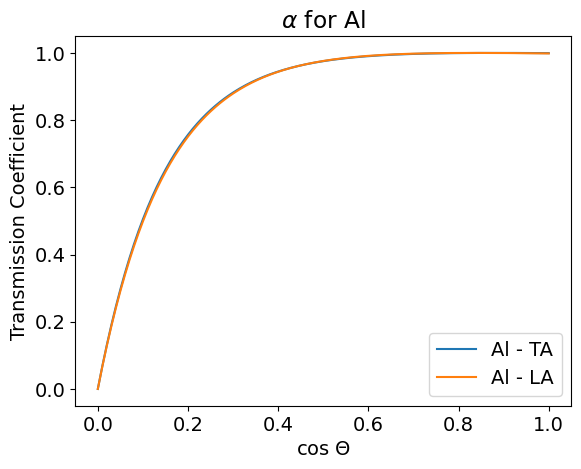

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_alpha_list(model, mu_list):
    return np.array([model.get_alpha(np.arccos(mu)) for mu in mu_list])

angle_num_bins = 300
mu_list = np.linspace(0, 1, angle_num_bins)
theta_list = np.linspace(0, np.pi/2, angle_num_bins)

# Assuming models dictionary is already created from the previous code
materials = materials = ['Al']
alpha_lists = {}

for material in materials:
    alpha_lists[material] = calculate_alpha_list(models[material], mu_list)

# Plotting the results
labels = ('TA', 'LA')

for material in materials:
    plt.figure()
    for alpha, label in zip(alpha_lists[material][:, 1:].T, labels):
        plt.plot(mu_list, alpha, label=f'{material} - {label}')
    plt.xlabel('cos $\Theta$')
    plt.ylabel('Transmission Coefficient')
    plt.legend()
    plt.title(f'$\u03B1$ for {material}')
    plt.savefig(f'{material}_alpha_Si_MD.png')
    plt.show()

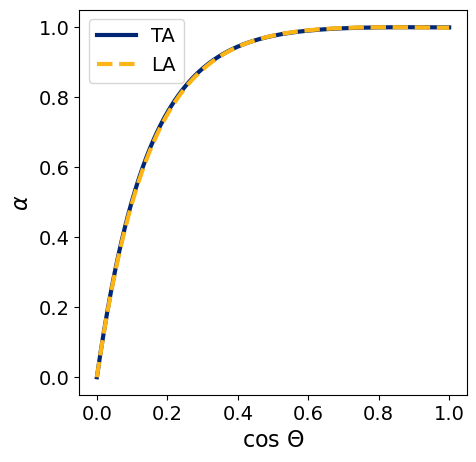

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_alpha_list(model, mu_list):
    return np.array([model.get_alpha(np.arccos(mu)) for mu in mu_list])

angle_num_bins = 300
mu_list = np.linspace(0, 1, angle_num_bins)

# Assuming models dictionary exists
materials_2 = ['Al']
alpha_lists = {}

for material in materials_2:
    alpha_lists[material] = calculate_alpha_list(models[material], mu_list)

# Plot settings
labels = ('TA', 'LA')
linestyles = ('-', '--')  # TA: solid, LA: dashed
colors = ['#002676', '#FDB515']  # Blue for TA, Gold for LA

# Create a single figure
plt.figure(figsize=(5, 5))

for material in materials_2:
    for alpha, label, color, ls in zip(alpha_lists[material][:, 1:].T, labels, colors, linestyles):
        plt.plot(mu_list, alpha, 
                 label=label, 
                 color=color, 
                 linewidth=3, 
                 linestyle=ls)

# Formatting
plt.tick_params(axis='both', colors='black')
for spine in plt.gca().spines.values():
    spine.set_color('black')

# Add labels
# Add labels
plt.xlabel('cos $\Theta$', fontsize=16)
plt.ylabel(r'$\alpha$', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)

# Font settings
plt.rcParams['font.family'] = 'Arial'


plt.savefig('Si_Al_Nov.png', dpi=400, bbox_inches='tight')
plt.show()

In [23]:
import numpy as np

# Assuming these variables already exist from your previous calculations:
# materials = ['Cs', 'InP', 'SiGe'] 
# alpha_lists = {material: calculated_alphas for material in materials}
# mu_list = your_cos_theta_values

for material in materials:
    # Prepare data: [cosθ, TA_alpha, LA_alpha]
    data = np.column_stack((
        mu_list,                        # cosθ values
        alpha_lists[material][:, 1],    # TA mode 
        alpha_lists[material][:, 2]     # LA mode
    ))
    
    # Save to text file
    header = f"cosθ\tTA_alpha\tLA_alpha"
    np.savetxt(f"{material}_alpha_Si_Al.txt", data, 
               header=header, 
               delimiter='\t', 
               fmt='%.6f', 
               comments='')

In [24]:
# Calculate and print the impedance for each material
for material in materials:
    model = models[material]
    Z_material = model.material_1.sound_speed * model.material_1.density
    Z_si = model.material_2.sound_speed * model.material_2.density
    print(f'Z_{material} = {Z_material}')
    print(f'Z_Si = {Z_si}')
    print(f'Z_{material}/Z_Si = {Z_material / Z_si}')
    print('---')

Z_Al = [ 9363201.55038862  9363201.5503885  19981523.74503025]
Z_Si = [ 8915661.97761756  8915661.97761744 18467638.15606596]
Z_Al/Z_Si = [1.05019701 1.05019701 1.08197505]
---


In [25]:
model.material_1.sound_speed

array([4104.54440175, 4104.54440175, 8759.29573712])

In [26]:
model.material_1.density

2281.179257410132

In [27]:
model.material_2.sound_speed

array([3289.23122214, 3289.23122214, 6813.21613299])

In [28]:
model.material_2.density

2710.561032498946

In [29]:
for material in materials:
    model = models[material]
    Z_material = model.material_1.sound_speed * model.material_1.density
    Z_si = model.material_2.sound_speed * model.material_2.density
    print(f'Z_{material} = {Z_material}')
    print(f'Z_Si = {Z_si}')
    print(f'Z_Si/Z_{material} = {Z_si / Z_material}')
    print('---')

Z_Al = [ 9363201.55038862  9363201.5503885  19981523.74503025]
Z_Si = [ 8915661.97761756  8915661.97761744 18467638.15606596]
Z_Si/Z_Al = [0.95220229 0.95220229 0.92423573]
---
